In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv(r"D:\SLA\Python\Projects\Churn_dataset.csv")
df

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110.0,45.07,...,99.0,16.78,244.7,91.0,11.01,10.0,3.0,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123.0,27.47,...,103.0,16.62,254.4,103.0,11.45,13.7,3.0,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114.0,41.38,...,110.0,10.30,162.6,104.0,7.32,12.2,5.0,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71.0,50.90,...,88.0,5.26,196.9,89.0,8.86,6.6,7.0,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113.0,28.34,...,122.0,12.61,186.9,121.0,8.41,10.1,3.0,2.73,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,AZ,192,415,414-4276,no,yes,36,156.2,77.0,26.55,...,126.0,18.32,279.1,83.0,12.56,9.9,6.0,2.67,2,False
3329,WV,68,415,370-3271,no,no,0,231.1,57.0,39.29,...,55.0,13.04,191.3,123.0,8.61,9.6,4.0,2.59,3,False
3330,RI,28,510,328-8230,no,no,0,180.8,109.0,30.74,...,58.0,24.55,191.9,91.0,8.64,14.1,6.0,3.81,2,False
3331,CT,184,510,364-6381,yes,no,0,213.8,105.0,36.35,...,84.0,13.57,139.2,137.0,6.26,5.0,10.0,1.35,2,False


In [231]:
df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110.0,45.07,...,99.0,16.78,244.7,91.0,11.01,10.0,3.0,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123.0,27.47,...,103.0,16.62,254.4,103.0,11.45,13.7,3.0,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114.0,41.38,...,110.0,10.30,162.6,104.0,7.32,12.2,5.0,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71.0,50.90,...,88.0,5.26,196.9,89.0,8.86,6.6,7.0,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113.0,28.34,...,122.0,12.61,186.9,121.0,8.41,10.1,3.0,2.73,3,False


In [232]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3330 non-null   float64
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3330 non-null   float64
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3328 non-null   

In [233]:
df.columns

Index(['state', 'account length', 'area code', 'phone number',
       'international plan', 'voice mail plan', 'number vmail messages',
       'total day minutes', 'total day calls', 'total day charge',
       'total eve minutes', 'total eve calls', 'total eve charge',
       'total night minutes', 'total night calls', 'total night charge',
       'total intl minutes', 'total intl calls', 'total intl charge',
       'customer service calls', 'churn'],
      dtype='object')

In [278]:
df.describe()

,state,account length,area code,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,...,churn,total_minutes,total_calls,avg_call_duration,day_charge_ratio,eve_charge_ratio,night_charge_ratio,intl_charge_ratio,high_service_calls,intl_vm
count,2944.000000,2944.000000,2944.000000,2944.000000,2944.000000,2944.000000,2944.000000,2944.000000,2944.000000,2944.000000,...,2944.000000,2944.000000,2944.000000,2944.000000,2944.000000,2944.000000,2944.000000,2944.000000,2944.0,2944.0
mean,26.138247,100.881793,437.142323,0.095448,0.279212,8.183764,180.061243,100.482337,30.610938,201.339266,...,0.110054,592.682711,306.433764,1.964976,0.170003,0.085001,0.045000,0.270058,0.0,0.0
std,14.800643,40.123208,42.359036,0.293883,0.448688,13.745213,52.783797,19.792425,8.973180,49.294976,...,0.313011,86.835778,45.639419,0.373881,0.000019,0.000016,0.000016,0.000320,0.0,0.0
min,0.000000,1.000000,408.000000,0.000000,0.000000,0.000000,37.700000,30.000000,6.410000,65.200000,...,0.000000,284.300000,173.000000,0.516485,0.169919,0.084948,0.044942,0.269048,0.0,0.0
25%,14.000000,73.000000,408.000000,0.000000,0.000000,0.000000,144.000000,87.000000,24.480000,167.100000,...,0.000000,533.900000,282.000000,1.714373,0.169989,0.084988,0.044988,0.269811,0.0,0.0
50%,26.000000,100.000000,415.000000,0.000000,0.000000,0.000000,180.000000,101.000000,30.600000,201.450000,...,0.000000,594.000000,305.000000,1.941350,0.170004,0.085000,0.045000,0.270000,0.0,0.0
75%,39.000000,128.000000,510.000000,0.000000,1.000000,20.000000,216.025000,114.000000,36.725000,235.525000,...,0.000000,652.250000,328.000000,2.194982,0.170017,0.085013,0.045012,0.270297,0.0,0.0
max,50.000000,243.000000,510.000000,1.000000,1.000000,51.000000,322.500000,163.000000,54.830000,337.100000,...,1.000000,882.200000,1195.000000,3.442105,0.170127,0.085075,0.045056,0.271429,0.0,0.0


In [234]:
df.isnull().sum()

state                     0
account length            0
area code                 0
phone number              0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total day calls           3
total day charge          0
total eve minutes         0
total eve calls           3
total eve charge          0
total night minutes       0
total night calls         5
total night charge        0
total intl minutes        0
total intl calls          5
total intl charge         0
customer service calls    0
churn                     0
dtype: int64

Text(0.5, 1.0, 'Distribution of International Calls')

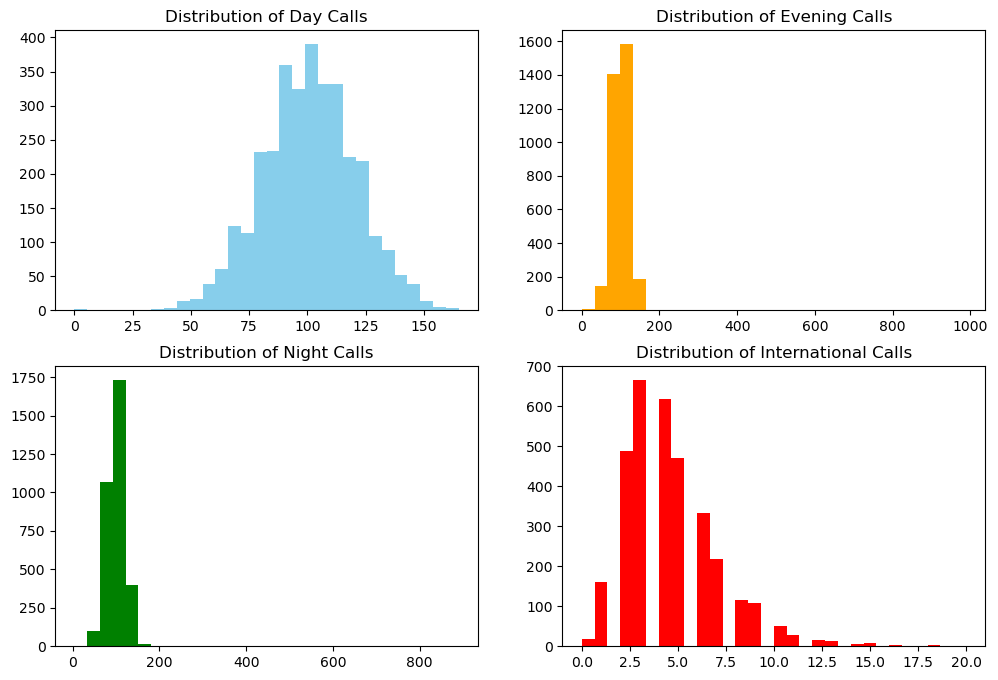

In [235]:
plt.subplots(2,2,figsize=(12,8))
plt.subplot(2,2,1)
plt.hist(df['total day calls'], bins=30, color='skyblue')
plt.title("Distribution of Day Calls")
plt.subplot(2,2,2)
plt.hist(df['total eve calls'], bins=30, color='orange')
plt.title("Distribution of Evening Calls")
plt.subplot(2,2,3)
plt.hist(df['total night calls'], bins=30, color='green')
plt.title("Distribution of Night Calls")
plt.subplot(2,2,4)
plt.hist(df['total intl calls'], bins=30, color='red')
plt.title("Distribution of International Calls")

In [236]:
null_cols = ['total day calls','total eve calls','total night calls','total intl calls']
for col in null_cols:
    df[col] = df[col].fillna(df[col].median())

In [237]:
df.isnull().sum()

state                     0
account length            0
area code                 0
phone number              0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total day calls           0
total day charge          0
total eve minutes         0
total eve calls           0
total eve charge          0
total night minutes       0
total night calls         0
total night charge        0
total intl minutes        0
total intl calls          0
total intl charge         0
customer service calls    0
churn                     0
dtype: int64

In [238]:
df = df.drop_duplicates()

In [239]:
df

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110.0,45.07,...,99.0,16.78,244.7,91.0,11.01,10.0,3.0,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123.0,27.47,...,103.0,16.62,254.4,103.0,11.45,13.7,3.0,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114.0,41.38,...,110.0,10.30,162.6,104.0,7.32,12.2,5.0,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71.0,50.90,...,88.0,5.26,196.9,89.0,8.86,6.6,7.0,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113.0,28.34,...,122.0,12.61,186.9,121.0,8.41,10.1,3.0,2.73,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,AZ,192,415,414-4276,no,yes,36,156.2,77.0,26.55,...,126.0,18.32,279.1,83.0,12.56,9.9,6.0,2.67,2,False
3329,WV,68,415,370-3271,no,no,0,231.1,57.0,39.29,...,55.0,13.04,191.3,123.0,8.61,9.6,4.0,2.59,3,False
3330,RI,28,510,328-8230,no,no,0,180.8,109.0,30.74,...,58.0,24.55,191.9,91.0,8.64,14.1,6.0,3.81,2,False
3331,CT,184,510,364-6381,yes,no,0,213.8,105.0,36.35,...,84.0,13.57,139.2,137.0,6.26,5.0,10.0,1.35,2,False


In [240]:
df['churn'] = df['churn'].astype(bool)
df['international plan'] = df['international plan'].astype('category')
df['voice mail plan'] = df['voice mail plan'].astype('category')

In [241]:
df['international plan'] = df['international plan'].cat.codes
df['voice mail plan']    = df['voice mail plan'].cat.codes

In [242]:
df

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,0,1,25,265.1,110.0,45.07,...,99.0,16.78,244.7,91.0,11.01,10.0,3.0,2.70,1,False
1,OH,107,415,371-7191,0,1,26,161.6,123.0,27.47,...,103.0,16.62,254.4,103.0,11.45,13.7,3.0,3.70,1,False
2,NJ,137,415,358-1921,0,0,0,243.4,114.0,41.38,...,110.0,10.30,162.6,104.0,7.32,12.2,5.0,3.29,0,False
3,OH,84,408,375-9999,1,0,0,299.4,71.0,50.90,...,88.0,5.26,196.9,89.0,8.86,6.6,7.0,1.78,2,False
4,OK,75,415,330-6626,1,0,0,166.7,113.0,28.34,...,122.0,12.61,186.9,121.0,8.41,10.1,3.0,2.73,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,AZ,192,415,414-4276,0,1,36,156.2,77.0,26.55,...,126.0,18.32,279.1,83.0,12.56,9.9,6.0,2.67,2,False
3329,WV,68,415,370-3271,0,0,0,231.1,57.0,39.29,...,55.0,13.04,191.3,123.0,8.61,9.6,4.0,2.59,3,False
3330,RI,28,510,328-8230,0,0,0,180.8,109.0,30.74,...,58.0,24.55,191.9,91.0,8.64,14.1,6.0,3.81,2,False
3331,CT,184,510,364-6381,1,0,0,213.8,105.0,36.35,...,84.0,13.57,139.2,137.0,6.26,5.0,10.0,1.35,2,False


In [243]:
df['churn'] = df['churn'].astype(int)

In [244]:
for col in ['state','international plan','voice mail plan']:
    df[col] = LabelEncoder().fit_transform(df[col])

In [245]:
df['total_minutes'] = (
    df['total day minutes'] +
    df['total eve minutes'] +
    df['total night minutes'] +
    df['total intl minutes']
)

df['total_calls'] = (
    df['total day calls'] +
    df['total eve calls'] +
    df['total night calls'] +
    df['total intl calls']
)

In [246]:
#Average Call Duration:
df['avg_call_duration'] = df['total_minutes'] / df['total_calls']

In [247]:
#Charges Ratio:
df['day_charge_ratio'] = df['total day charge'] / df['total day minutes']
df['eve_charge_ratio'] = df['total eve charge'] / df['total eve minutes']
df['night_charge_ratio'] = df['total night charge'] / df['total night minutes']
df['intl_charge_ratio'] = df['total intl charge'] / df['total intl minutes']

In [248]:
#High_service_calls:
df['high_service_calls'] = (df['customer service calls'] > 3).astype(int)

In [249]:
#Plan Interaction :
df['intl_vm'] = (
    (df['international plan'] == 'yes') & 
    (df['voice mail plan'] == 'yes')
).astype(int)

In [250]:
df

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,churn,total_minutes,total_calls,avg_call_duration,day_charge_ratio,eve_charge_ratio,night_charge_ratio,intl_charge_ratio,high_service_calls,intl_vm
0,16,128,415,382-4657,0,1,25,265.1,110.0,45.07,...,0,717.2,303.0,2.366997,0.170011,0.085005,0.044994,0.270000,0,0
1,35,107,415,371-7191,0,1,26,161.6,123.0,27.47,...,0,625.2,332.0,1.883133,0.169988,0.085013,0.045008,0.270073,0,0
2,31,137,415,358-1921,0,0,0,243.4,114.0,41.38,...,0,539.4,333.0,1.619820,0.170008,0.084983,0.045018,0.269672,0,0
3,35,84,408,375-9999,1,0,0,299.4,71.0,50.90,...,0,564.8,255.0,2.214902,0.170007,0.084976,0.044997,0.269697,0,0
4,36,75,415,330-6626,1,0,0,166.7,113.0,28.34,...,0,512.0,359.0,1.426184,0.170006,0.085030,0.044997,0.270297,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,3,192,415,414-4276,0,1,36,156.2,77.0,26.55,...,0,660.7,292.0,2.262671,0.169974,0.085012,0.045002,0.269697,0,0
3329,49,68,415,370-3271,0,0,0,231.1,57.0,39.29,...,0,585.4,239.0,2.449372,0.170013,0.085007,0.045008,0.269792,0,0
3330,39,28,510,328-8230,0,0,0,180.8,109.0,30.74,...,0,675.6,264.0,2.559091,0.170022,0.085007,0.045023,0.270213,0,0
3331,6,184,510,364-6381,1,0,0,213.8,105.0,36.35,...,0,517.6,336.0,1.540476,0.170019,0.085025,0.044971,0.270000,0,0


Text(0.5, 1.0, 'Churn Distribution')

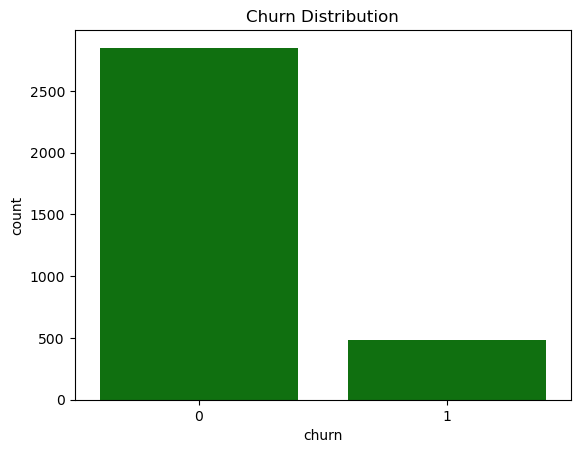

In [251]:
#Churn distribution
sns.countplot(x='churn', color ="green",data=df)
plt.title("Churn Distribution")

Text(0.5, 1.0, 'Churn vs Customer Service Calls')

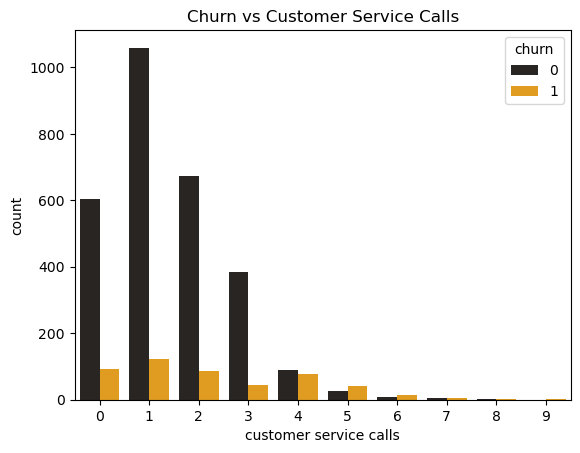

In [252]:
#Customer service calls vs churn:
sns.countplot(x='customer service calls', hue='churn',palette='dark:orange', data=df)
plt.title("Churn vs Customer Service Calls")

Text(0.5, 1.0, 'Correlation with Churn')

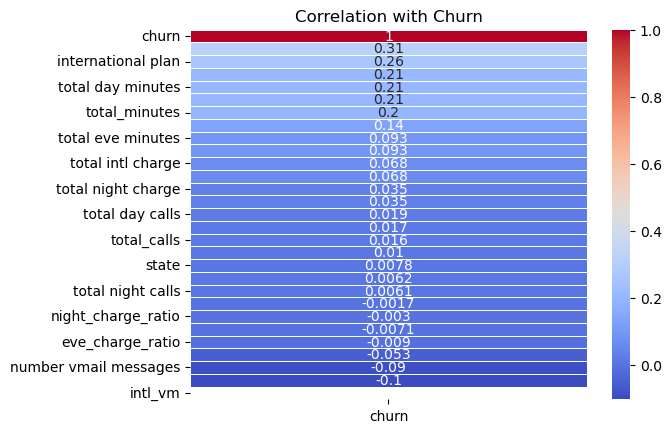

In [253]:
#Correlation matrix
corr = df.select_dtypes(include=['number']).corr()
corr_churn = corr[['churn']].sort_values(by='churn', ascending=False)
sns.heatmap(corr_churn, cmap="coolwarm", annot=True, linewidths=0.5, linecolor='white')
plt.title("Correlation with Churn")

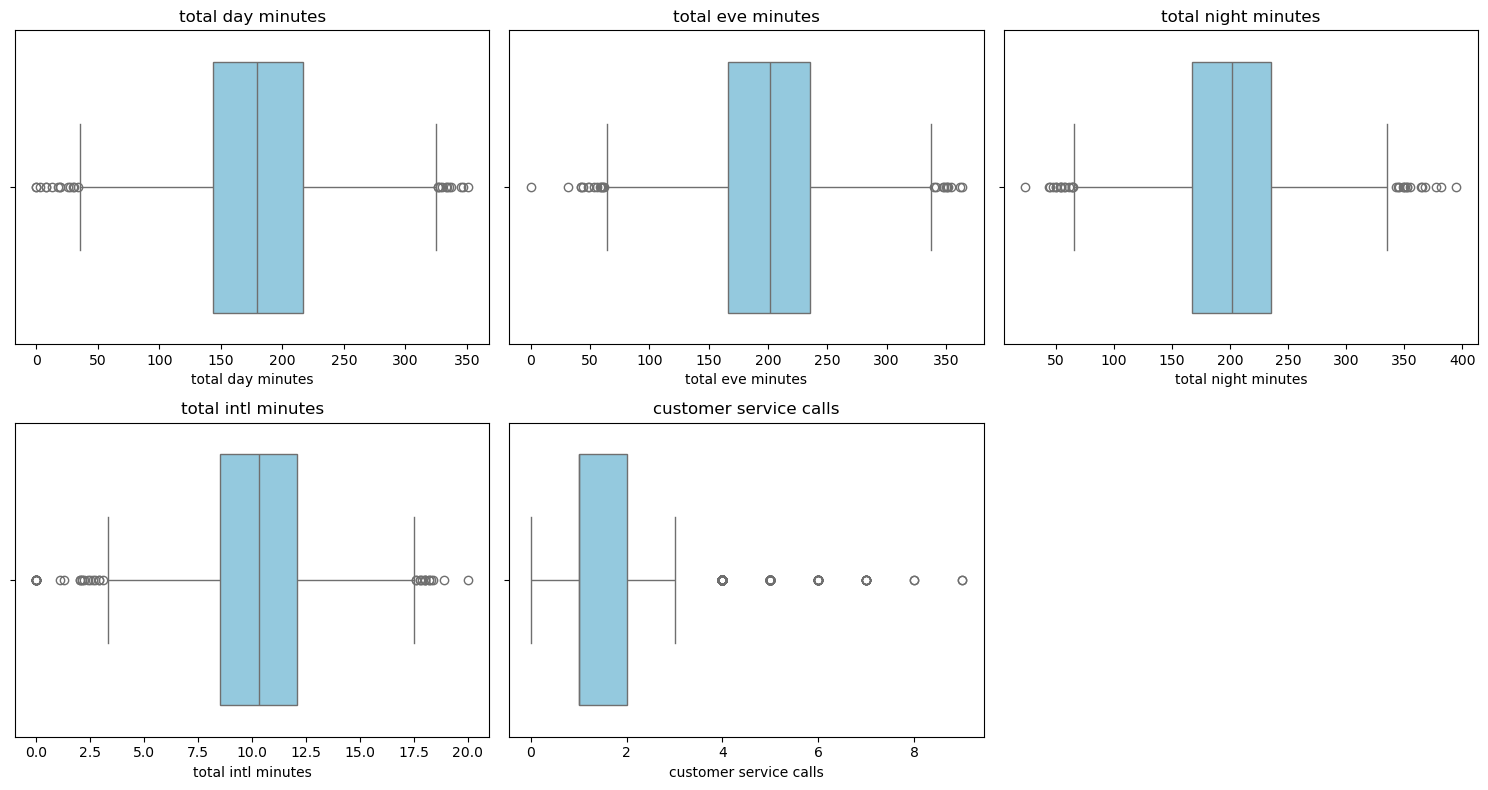

In [254]:
cols = ['total day minutes','total eve minutes','total night minutes',
        'total intl minutes','customer service calls']

plt.figure(figsize=(15,8))
for i, col in enumerate(cols, 1):
    plt.subplot(2,3,i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(col)
plt.tight_layout()

In [265]:
cols = ['total day minutes','total eve minutes','total night minutes',
        'total intl minutes','customer service calls']

for col in cols:
    Q1 = np.percentile(df[col].dropna(), 25)
    Q3 = np.percentile(df[col].dropna(), 75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    print(f"{col} → Q1:{Q1}, Q3:{Q3}, IQR:{IQR}, Limits:[{lower_limit}, {upper_limit}]")

    outliers = []
    for x in df[col].dropna():
        if (x < lower_limit) or (x > upper_limit):
            outliers.append(x)
    print(f"Outliers in {col}:", outliers)

# Removing the outliers:
df = df[(df[col] >= lower_limit) & (df[col] <= upper_limit)]

total day minutes → Q1:144.0, Q3:216.025, IQR:72.025, Limits:[35.96249999999999, 324.0625]
Outliers in total day minutes: []
total eve minutes → Q1:167.1, Q3:235.525, IQR:68.42500000000001, Limits:[64.46249999999998, 338.1625]
Outliers in total eve minutes: []
total night minutes → Q1:167.575, Q3:235.32500000000002, IQR:67.75000000000003, Limits:[65.94999999999995, 336.95000000000005]
Outliers in total night minutes: [65.8]
total intl minutes → Q1:8.5, Q3:12.1, IQR:3.5999999999999996, Limits:[3.1000000000000005, 17.5]
Outliers in total intl minutes: []
customer service calls → Q1:1.0, Q3:2.0, IQR:1.0, Limits:[-0.5, 3.5]
Outliers in customer service calls: []


Text(0.5, 1.0, 'Churn by State')

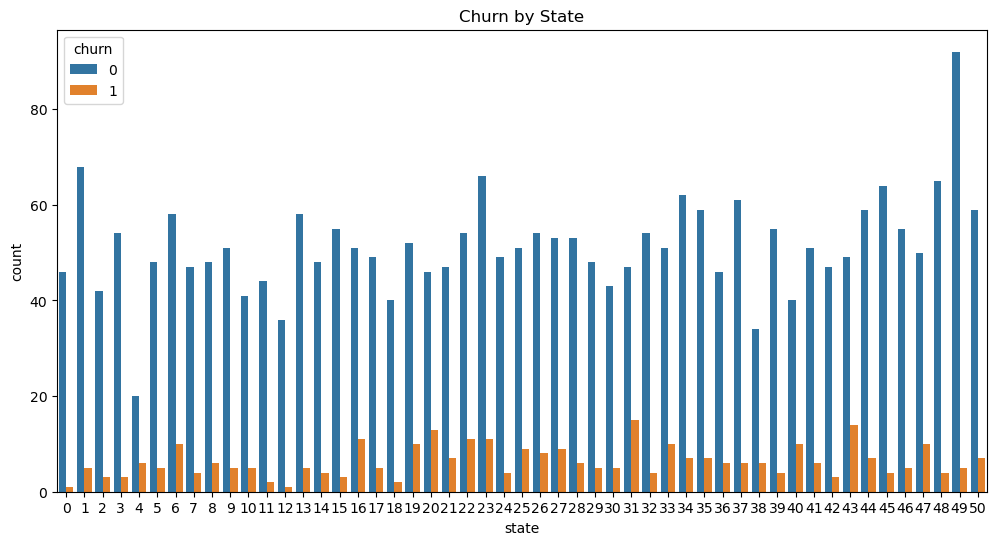

In [271]:
plt.figure(figsize=(12,6))
sns.countplot(x='state', hue='churn', data=df)
plt.title("Churn by State")

Text(0.5, 1.0, 'Day Charge vs Customer Service Calls')

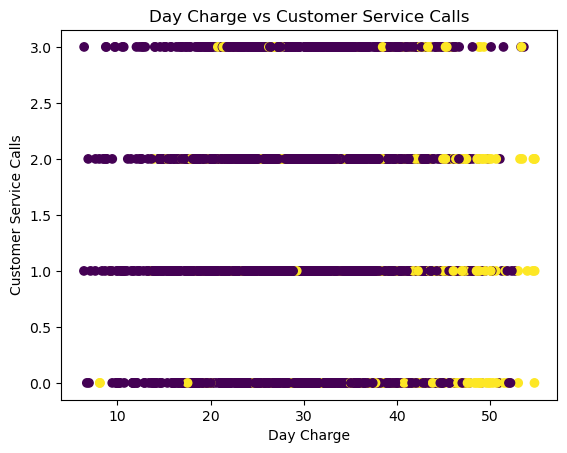

In [272]:
plt.scatter(df['total day charge'], df['customer service calls'], c=df['churn'])
plt.xlabel("Day Charge")
plt.ylabel("Customer Service Calls")
plt.title("Day Charge vs Customer Service Calls")

Text(0.5, 1.0, 'Churn Proportion')

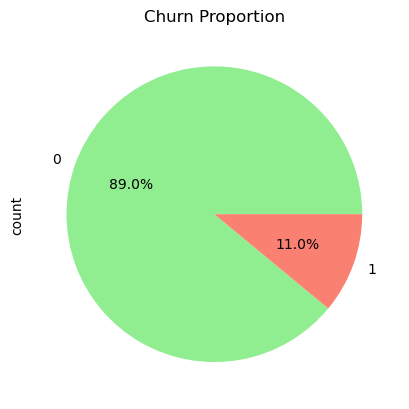

In [273]:
df['churn'].value_counts().plot.pie(autopct='%1.1f%%', colors=['lightgreen','salmon'])
plt.title("Churn Proportion")

In [16]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [19]:
print(df.columns)

Index(['state', 'account_length', 'area_code', 'phone_number',
       'international_plan', 'voice_mail_plan', 'number_vmail_messages',
       'total_day_minutes', 'total_day_calls', 'total_day_charge',
       'total_eve_minutes', 'total_eve_calls', 'total_eve_charge',
       'total_night_minutes', 'total_night_calls', 'total_night_charge',
       'total_intl_minutes', 'total_intl_calls', 'total_intl_charge',
       'customer_service_calls', 'churn'],
      dtype='object')


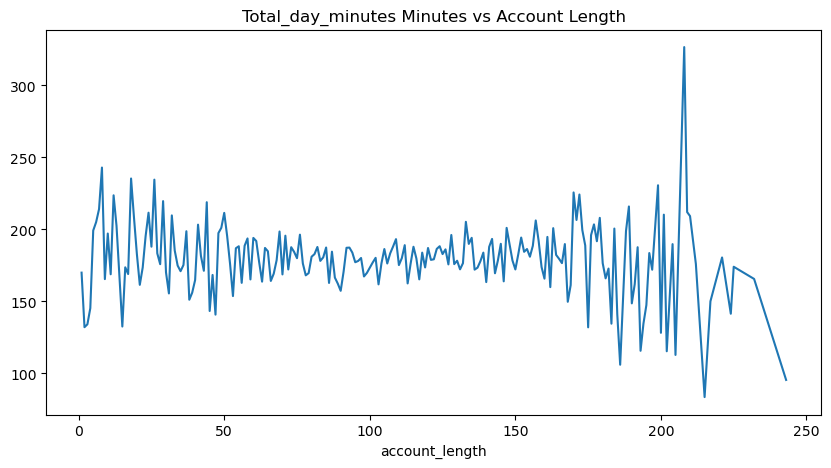

In [22]:
df.groupby('account_length')['total_day_minutes'].mean().plot(
    kind='line',
    figsize=(10,5)
)

plt.title("Total_day_minutes Minutes vs Account Length")

In [6]:
df.to_csv(r"D:\SLA\Projects\Churn_Data_Analysis.csv", index=False)

In [7]:
df.to_csv("Churn_Data_Analysis.csv", index=False)